In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("  PREDIKSI GAJI KARYAWAN - MACHINE LEARNING")

  PREDIKSI GAJI KARYAWAN - MACHINE LEARNING


## [1] Eksplorasi Data Awal

In [2]:
df = pd.read_csv('data_karyawan.csv')

print("\n[1] EKSPLORASI DATA AWAL")
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"\nTipe data setiap kolom:")
print(df.dtypes)
print(f"\nJumlah nilai kosong (NaN):")
print(df.isnull().sum())
print(f"\nStatistik deskriptif:")
print(df.describe())


[1] EKSPLORASI DATA AWAL
Jumlah baris   : 100
Jumlah kolom   : 5

Tipe data setiap kolom:
usia                  int64
pengalaman_kerja    float64
jenis_kelamin           str
pendidikan              str
gaji                float64
dtype: object

Jumlah nilai kosong (NaN):
usia                0
pengalaman_kerja    5
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64

Statistik deskriptif:
             usia  pengalaman_kerja          gaji
count  100.000000         95.000000  1.000000e+02
mean    37.910000          8.442105  5.039610e+06
std     12.219454          6.011896  1.086690e+06
min     18.000000          0.000000  1.759000e+06
25%     26.750000          3.500000  4.330250e+06
50%     38.000000          8.000000  5.067000e+06
75%     46.250000         13.500000  5.681500e+06
max     59.000000         19.000000  8.853000e+06


## [2] Preprocessing Data

In [3]:
print("\n[2] PREPROCESSING DATA")

print(">> Imputasi pengalaman_kerja (NaN) menggunakan MEAN IMPUTATION")
imputer = SimpleImputer(strategy='mean')
df['pengalaman_kerja'] = imputer.fit_transform(df[['pengalaman_kerja']])
print(f"   Nilai mean yang digunakan: {df['pengalaman_kerja'].mean():.2f} tahun")
print(f"   Nilai NaN setelah imputasi: {df['pengalaman_kerja'].isnull().sum()}")

print("\n>> Binary Encoding kolom 'jenis_kelamin'")
print("   Pria = 1  |  Wanita = 0")
df['jenis_kelamin_enc'] = df['jenis_kelamin'].map({'Pria': 1, 'Wanita': 0})

print("\n>> Ordinal Encoding kolom 'pendidikan'")
print("   SMA=0, D3=1, S1=2, S2=3  (sesuai jenjang)")
edu_order = [['SMA', 'D3', 'S1', 'S2']]
ord_enc = OrdinalEncoder(categories=edu_order)
df['pendidikan_enc'] = ord_enc.fit_transform(df[['pendidikan']]).astype(int)
print(f"   Mapping: {dict(zip(['SMA','D3','S1','S2'], [0,1,2,3]))}")

print("\nDataframe setelah preprocessing (5 baris pertama):")
print(df[['usia','pengalaman_kerja','jenis_kelamin_enc','pendidikan_enc','gaji']].head())


[2] PREPROCESSING DATA
>> Imputasi pengalaman_kerja (NaN) menggunakan MEAN IMPUTATION
   Nilai mean yang digunakan: 8.44 tahun
   Nilai NaN setelah imputasi: 0

>> Binary Encoding kolom 'jenis_kelamin'
   Pria = 1  |  Wanita = 0

>> Ordinal Encoding kolom 'pendidikan'
   SMA=0, D3=1, S1=2, S2=3  (sesuai jenjang)
   Mapping: {'SMA': 0, 'D3': 1, 'S1': 2, 'S2': 3}

Dataframe setelah preprocessing (5 baris pertama):
   usia  pengalaman_kerja  jenis_kelamin_enc  pendidikan_enc       gaji
0    56               8.0                  0               3  5058000.0
1    46               7.0                  0               0  3857000.0
2    32              11.0                  1               0  5358000.0
3    25               1.0                  1               3  5561000.0
4    38               0.0                  0               0  6083000.0


## [3] Feature Engineering & Train-Test Split

In [4]:
print("\n[3] FEATURE ENGINEERING & TRAIN-TEST SPLIT")

fitur = ['usia', 'pengalaman_kerja', 'jenis_kelamin_enc', 'pendidikan_enc']
target = 'gaji'

X = df[fitur]
y = df[target]

print(">> Korelasi fitur dengan gaji:")
for f in fitur:
    corr = df[f].corr(df[target])
    print(f"   {f:<25}: {corr:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n>> Train size : {X_train.shape[0]} data (80%)")
print(f"   Test size  : {X_test.shape[0]} data (20%)")


[3] FEATURE ENGINEERING & TRAIN-TEST SPLIT
>> Korelasi fitur dengan gaji:
   usia                     : 0.0842
   pengalaman_kerja         : -0.0901
   jenis_kelamin_enc        : -0.0373
   pendidikan_enc           : 0.1392

>> Train size : 80 data (80%)
   Test size  : 20 data (20%)


## [4] Pelatihan Model

In [5]:
print("\n[4] PELATIHAN MODEL")

print(">> Melatih Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print(f"   Intercept   : Rp {lr_model.intercept_:,.0f}")
for fname, coef in zip(fitur, lr_model.coef_):
    print(f"   Koef {fname:<22}: {coef:,.2f}")

print("\n>> Melatih Decision Tree Regressor...")
dt_model = DecisionTreeRegressor(max_depth=4, min_samples_split=5, random_state=42)
dt_model.fit(X_train, y_train)
print(f"   Max depth   : {dt_model.max_depth}")
print(f"   Min samples split: {dt_model.min_samples_split}")


[4] PELATIHAN MODEL
>> Melatih Linear Regression...
   Intercept   : Rp 4,826,165
   Koef usia                  : 8,275.53
   Koef pengalaman_kerja      : -24,383.58
   Koef jenis_kelamin_enc     : -233,063.00
   Koef pendidikan_enc        : 104,289.37

>> Melatih Decision Tree Regressor...
   Max depth   : 4
   Min samples split: 5


## [5] Evaluasi Model

In [6]:
print("\n[5] EVALUASI MODEL")

y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

def evaluasi(nama, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n  [{nama}]")
    print(f"   MAE  (Mean Absolute Error)  : Rp {mae:>12,.0f}")
    print(f"   MSE  (Mean Squared Error)   :    {mse:>15,.0f}")
    print(f"   RMSE (Root MSE)             : Rp {rmse:>12,.0f}")
    print(f"   R\u00b2   Score                  :    {r2:>12.4f}")
    return mae, mse, rmse, r2

mae_lr, mse_lr, rmse_lr, r2_lr   = evaluasi("LINEAR REGRESSION", y_test, y_pred_lr)
mae_dt, mse_dt, rmse_dt, r2_dt   = evaluasi("DECISION TREE", y_test, y_pred_dt)

print("\n>> Ringkasan Perbandingan Model:")
print(f"   {'Metrik':<10} {'Linear Reg':>15} {'Decision Tree':>15} {'Lebih Baik':>15}")
print(f"   {'MAE':<10} {mae_lr:>15,.0f} {mae_dt:>15,.0f} {'LR' if mae_lr<mae_dt else 'DT':>15}")
print(f"   {'RMSE':<10} {rmse_lr:>15,.0f} {rmse_dt:>15,.0f} {'LR' if rmse_lr<rmse_dt else 'DT':>15}")
print(f"   {'R\u00b2':<10} {r2_lr:>15.4f} {r2_dt:>15.4f} {'LR' if r2_lr>r2_dt else 'DT':>15}")

best_model = lr_model if r2_lr >= r2_dt else dt_model
best_name  = "Linear Regression" if r2_lr >= r2_dt else "Decision Tree"
print(f"\n>> Model Terpilih: {best_name} (R\u00b2 lebih tinggi)")


[5] EVALUASI MODEL

  [LINEAR REGRESSION]
   MAE  (Mean Absolute Error)  : Rp      724,352
   MSE  (Mean Squared Error)   :    841,167,798,092
   RMSE (Root MSE)             : Rp      917,152
   R²   Score                  :         -0.2638

  [DECISION TREE]
   MAE  (Mean Absolute Error)  : Rp      833,566
   MSE  (Mean Squared Error)   :    1,132,990,463,388
   RMSE (Root MSE)             : Rp    1,064,420
   R²   Score                  :         -0.7023

>> Ringkasan Perbandingan Model:
   Metrik          Linear Reg   Decision Tree      Lebih Baik
   MAE                724,352         833,566              LR
   RMSE               917,152       1,064,420              LR
   R²                 -0.2638         -0.7023              LR

>> Model Terpilih: Linear Regression (R² lebih tinggi)


## [6] Prediksi Gaji Karyawan Baru

In [7]:
print("\n[6] PREDIKSI GAJI KARYAWAN BARU")

karyawan_baru = pd.DataFrame({
    'usia':               [28, 35, 45],
    'pengalaman_kerja':   [3,  10,  20],
    'jenis_kelamin_enc':  [1,   0,   1],   # Pria=1, Wanita=0
    'pendidikan_enc':     [2,   3,   1],   # S1=2, S2=3, D3=1
})

pred_lr_baru = lr_model.predict(karyawan_baru)
pred_dt_baru = dt_model.predict(karyawan_baru)

print(f"\n  {'No':<4} {'Usia':<6} {'Exp':<5} {'Gender':<8} {'Pend':<6} {'Prediksi LR':>14} {'Prediksi DT':>14}")
print(f"  {'-'*60}")
genders = ['Pria', 'Wanita', 'Pria']
pendidikans = ['S1', 'S2', 'D3']
for i in range(len(karyawan_baru)):
    print(f"  {i+1:<4} {karyawan_baru['usia'].iloc[i]:<6} "
          f"{karyawan_baru['pengalaman_kerja'].iloc[i]:<5} "
          f"{genders[i]:<8} {pendidikans[i]:<6} "
          f"Rp {pred_lr_baru[i]:>10,.0f} "
          f"Rp {pred_dt_baru[i]:>10,.0f}")


[6] PREDIKSI GAJI KARYAWAN BARU

  No   Usia   Exp   Gender   Pend      Prediksi LR    Prediksi DT
  ------------------------------------------------------------
  1    28     3     Pria     S1     Rp  4,960,244 Rp  4,972,653
  2    35     10    Wanita   S2     Rp  5,184,841 Rp  4,972,653
  3    45     20    Pria     D3     Rp  4,582,118 Rp  3,949,750


## [7] Visualisasi


[7] MEMBUAT VISUALISASI...


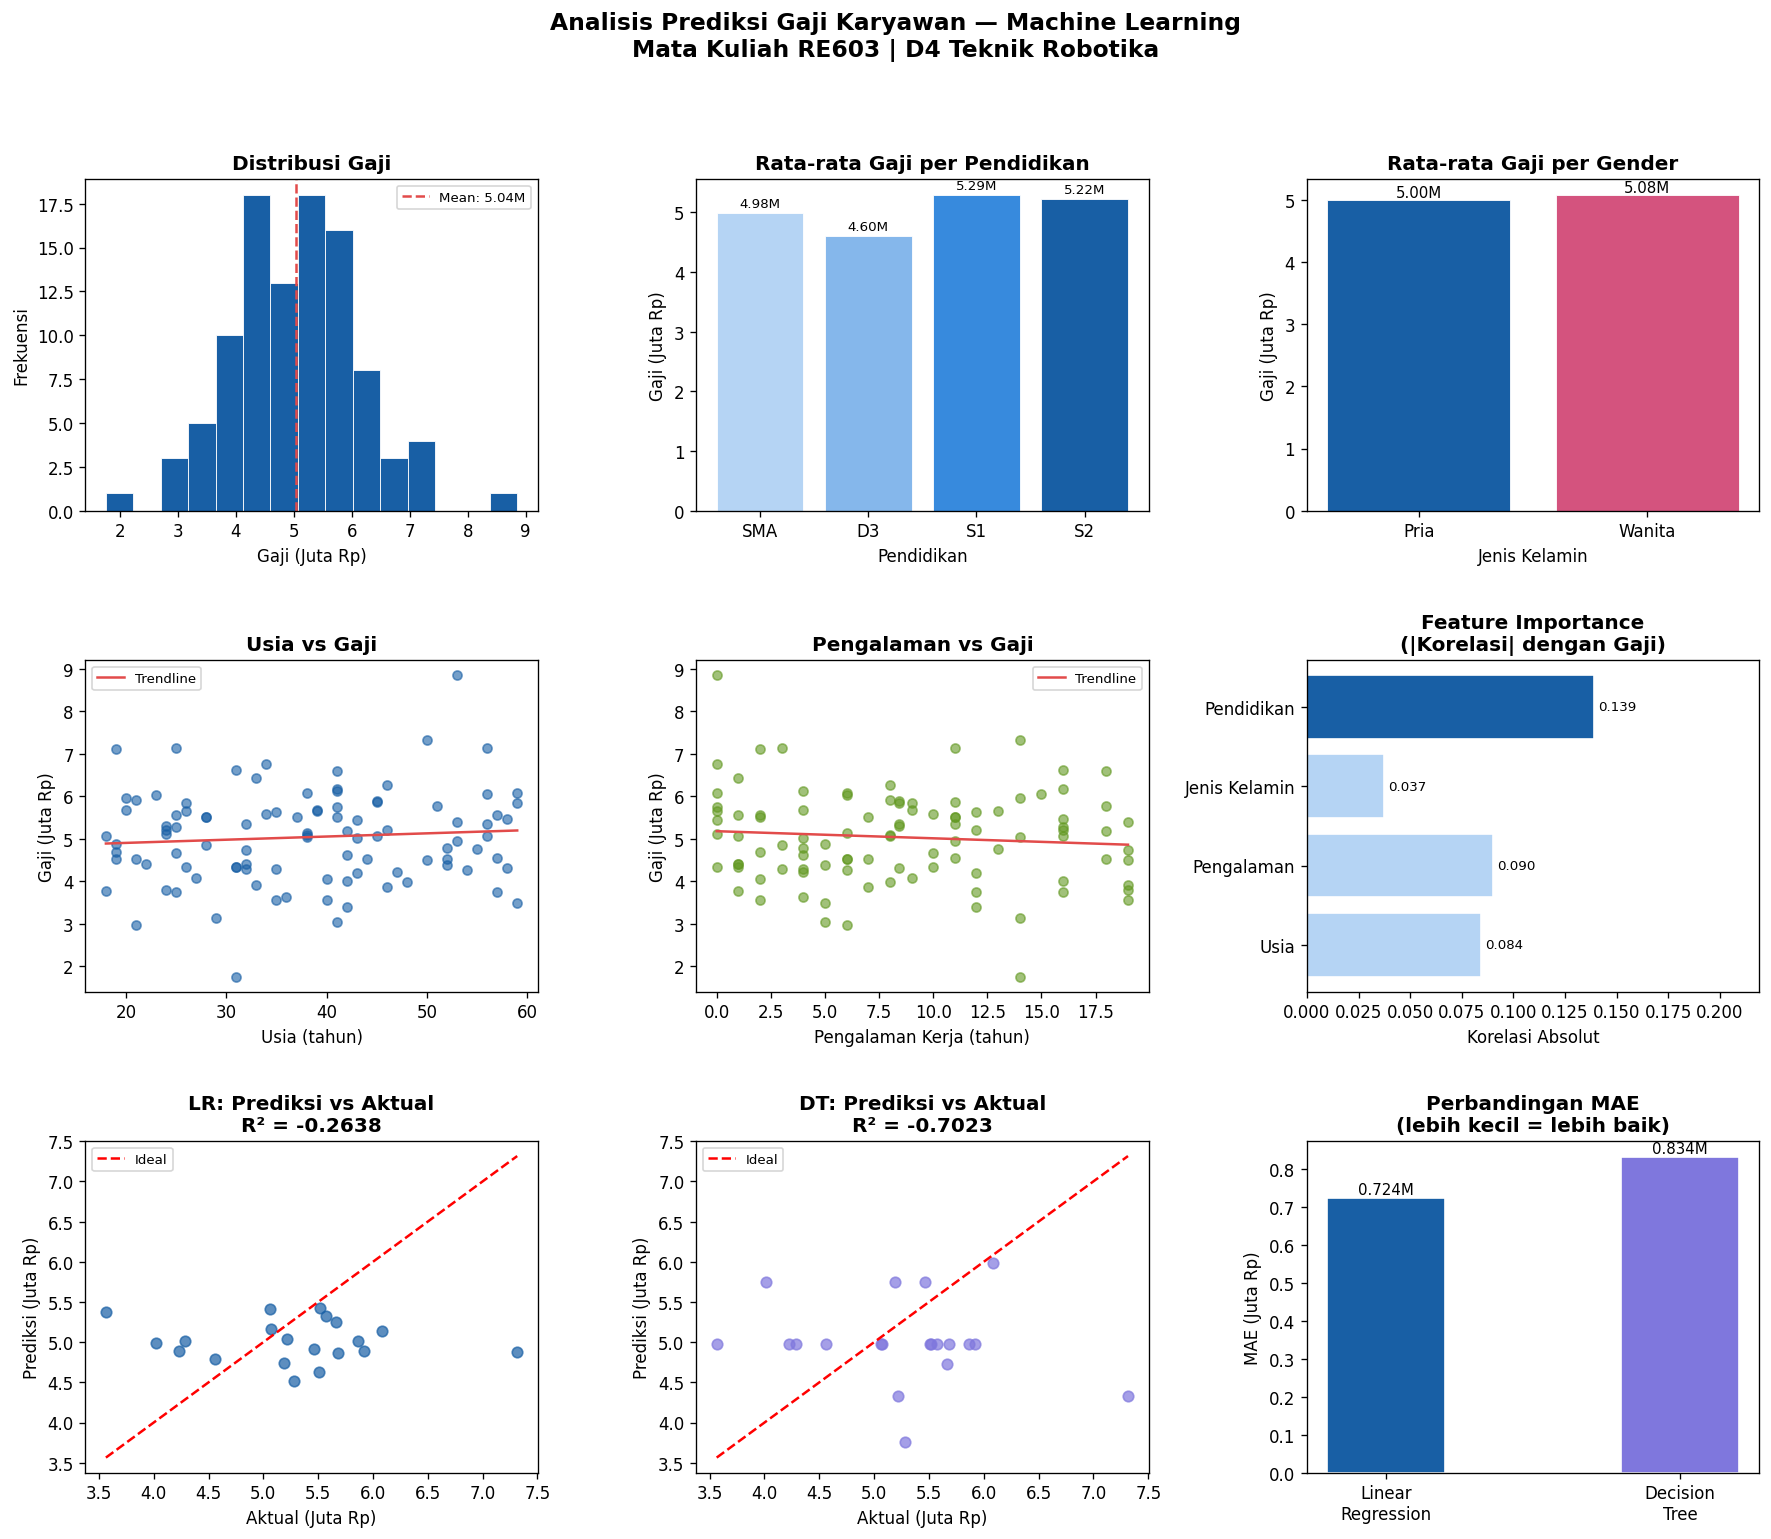

   Visualisasi disimpan: hasil_visualisasi.png


In [8]:
print("\n[7] MEMBUAT VISUALISASI...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Analisis Prediksi Gaji Karyawan — Machine Learning\nMata Kuliah RE603 | D4 Teknik Robotika',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Distribusi Gaji ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['gaji']/1e6, bins=15, color='#185FA5', edgecolor='white', linewidth=0.5)
ax1.set_title('Distribusi Gaji', fontweight='bold')
ax1.set_xlabel('Gaji (Juta Rp)')
ax1.set_ylabel('Frekuensi')
ax1.axvline(df['gaji'].mean()/1e6, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Mean: {df["gaji"].mean()/1e6:.2f}M')
ax1.legend(fontsize=8)

# --- Plot 2: Rata-rata Gaji per Pendidikan ---
ax2 = fig.add_subplot(gs[0, 1])
edu_salary = df.groupby('pendidikan')['gaji'].mean() / 1e6
edu_order_plot = ['SMA','D3','S1','S2']
edu_vals = [edu_salary.get(e, 0) for e in edu_order_plot]
colors_edu = ['#B5D4F4','#85B7EB','#378ADD','#185FA5']
bars = ax2.bar(edu_order_plot, edu_vals, color=colors_edu, edgecolor='white', linewidth=0.5)
ax2.set_title('Rata-rata Gaji per Pendidikan', fontweight='bold')
ax2.set_xlabel('Pendidikan')
ax2.set_ylabel('Gaji (Juta Rp)')
for bar, val in zip(bars, edu_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}M', ha='center', va='bottom', fontsize=8)

# --- Plot 3: Rata-rata Gaji per Gender ---
ax3 = fig.add_subplot(gs[0, 2])
gen_salary = df.groupby('jenis_kelamin')['gaji'].mean() / 1e6
ax3.bar(gen_salary.index, gen_salary.values,
        color=['#185FA5','#D4537E'], edgecolor='white', linewidth=0.5)
ax3.set_title('Rata-rata Gaji per Gender', fontweight='bold')
ax3.set_xlabel('Jenis Kelamin')
ax3.set_ylabel('Gaji (Juta Rp)')
for i, (idx, val) in enumerate(gen_salary.items()):
    ax3.text(i, val + 0.05, f'{val:.2f}M', ha='center', fontsize=9)

# --- Plot 4: Scatter Usia vs Gaji ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(df['usia'], df['gaji']/1e6, alpha=0.6, color='#185FA5', s=30)
ax4.set_title('Usia vs Gaji', fontweight='bold')
ax4.set_xlabel('Usia (tahun)')
ax4.set_ylabel('Gaji (Juta Rp)')
m, b = np.polyfit(df['usia'], df['gaji']/1e6, 1)
ax4.plot(sorted(df['usia']), [m*x+b for x in sorted(df['usia'])],
         color='#E24B4A', linewidth=1.5, label='Trendline')
ax4.legend(fontsize=8)

# --- Plot 5: Scatter Pengalaman vs Gaji ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df['pengalaman_kerja'], df['gaji']/1e6, alpha=0.6, color='#639922', s=30)
ax5.set_title('Pengalaman vs Gaji', fontweight='bold')
ax5.set_xlabel('Pengalaman Kerja (tahun)')
ax5.set_ylabel('Gaji (Juta Rp)')
m2, b2 = np.polyfit(df['pengalaman_kerja'], df['gaji']/1e6, 1)
ax5.plot(sorted(df['pengalaman_kerja']), [m2*x+b2 for x in sorted(df['pengalaman_kerja'])],
         color='#E24B4A', linewidth=1.5, label='Trendline')
ax5.legend(fontsize=8)

# --- Plot 6: Feature Importance (korelasi) ---
ax6 = fig.add_subplot(gs[1, 2])
feat_names = ['Usia', 'Pengalaman', 'Jenis Kelamin', 'Pendidikan']
corrs = [abs(df[f].corr(df['gaji'])) for f in fitur]
colors_fi = ['#185FA5' if c == max(corrs) else '#B5D4F4' for c in corrs]
bars_fi = ax6.barh(feat_names, corrs, color=colors_fi, edgecolor='white')
ax6.set_title('Feature Importance\n(|Korelasi| dengan Gaji)', fontweight='bold')
ax6.set_xlabel('Korelasi Absolut')
for bar, val in zip(bars_fi, corrs):
    ax6.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)
ax6.set_xlim(0, max(corrs) + 0.08)

# --- Plot 7: Prediksi vs Aktual LR ---
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(y_test/1e6, y_pred_lr/1e6, alpha=0.7, color='#185FA5', s=40)
mn_val = min(y_test.min(), y_pred_lr.min())/1e6
mx_val = max(y_test.max(), y_pred_lr.max())/1e6
ax7.plot([mn_val, mx_val], [mn_val, mx_val], 'r--', linewidth=1.5, label='Ideal')
ax7.set_title(f'LR: Prediksi vs Aktual\nR\u00b2 = {r2_lr:.4f}', fontweight='bold')
ax7.set_xlabel('Aktual (Juta Rp)')
ax7.set_ylabel('Prediksi (Juta Rp)')
ax7.legend(fontsize=8)

# --- Plot 8: Prediksi vs Aktual DT ---
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(y_test/1e6, y_pred_dt/1e6, alpha=0.7, color='#7F77DD', s=40)
ax8.plot([mn_val, mx_val], [mn_val, mx_val], 'r--', linewidth=1.5, label='Ideal')
ax8.set_title(f'DT: Prediksi vs Aktual\nR\u00b2 = {r2_dt:.4f}', fontweight='bold')
ax8.set_xlabel('Aktual (Juta Rp)')
ax8.set_ylabel('Prediksi (Juta Rp)')
ax8.legend(fontsize=8)

# --- Plot 9: Perbandingan MAE ---
ax9 = fig.add_subplot(gs[2, 2])
models = ['Linear\nRegression', 'Decision\nTree']
mae_vals = [mae_lr/1e6, mae_dt/1e6]
x_pos = np.arange(len(models))
bars9 = ax9.bar(x_pos, mae_vals, color=['#185FA5','#7F77DD'], edgecolor='white', width=0.4)
ax9.set_title('Perbandingan MAE\n(lebih kecil = lebih baik)', fontweight='bold')
ax9.set_ylabel('MAE (Juta Rp)')
ax9.set_xticks(x_pos)
ax9.set_xticklabels(models)
for bar, val in zip(bars9, mae_vals):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}M', ha='center', fontsize=9)

plt.savefig('hasil_visualisasi.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("   Visualisasi disimpan: hasil_visualisasi.png")

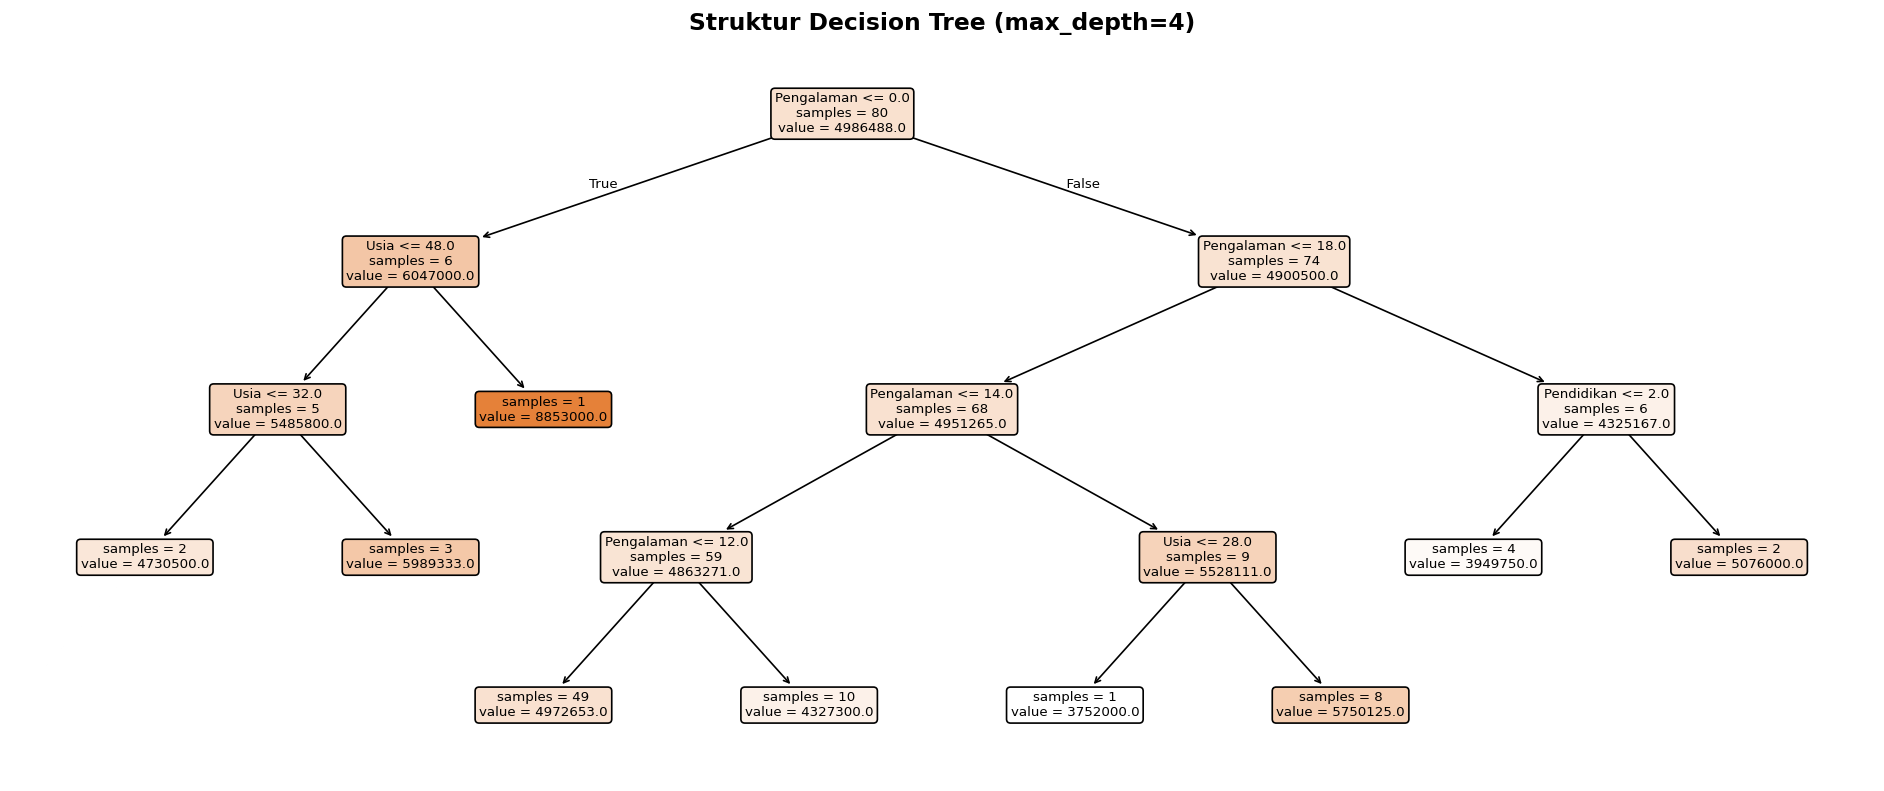

   Struktur DT disimpan  : decision_tree_struktur.png


In [9]:
fig_tree, ax_tree = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, feature_names=['Usia', 'Pengalaman', 'Jenis Kelamin', 'Pendidikan'],
          filled=True, rounded=True, fontsize=8, ax=ax_tree,
          impurity=False, precision=0)
ax_tree.set_title('Struktur Decision Tree (max_depth=4)', fontsize=14, fontweight='bold')
plt.savefig('decision_tree_struktur.png', dpi=120, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("   Struktur DT disimpan  : decision_tree_struktur.png")

## [8] Analisis Residual

In [10]:
print("\n[8] ANALISIS RESIDUAL (Pengganti Confusion Matrix untuk Regresi)")
residual_lr = y_test.values - y_pred_lr
residual_dt = y_test.values - y_pred_dt

print(f"  Linear Regression:")
print(f"   Mean Residual   : Rp {residual_lr.mean():>10,.0f}")
print(f"   Std Residual    : Rp {residual_lr.std():>10,.0f}")
print(f"  Decision Tree:")
print(f"   Mean Residual   : Rp {residual_dt.mean():>10,.0f}")
print(f"   Std Residual    : Rp {residual_dt.std():>10,.0f}")





[8] ANALISIS RESIDUAL (Pengganti Confusion Matrix untuk Regresi)
  Linear Regression:
   Mean Residual   : Rp    238,779
   Std Residual    : Rp    885,524
  Decision Tree:
   Mean Residual   : Rp    249,668
   Std Residual    : Rp  1,034,725


soal no 2
Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari
studi kasus masing-masing.

Pengertian Feature Engineering
Feature engineering adalah proses mengubah data mentah menjadi representasi yang lebih bermakna agar model machine learning dapat belajar dan membuat prediksi dengan lebih baik. Proses ini mencakup pemilihan, transformasi, pembuatan fitur baru, serta penanganan data yang tidak bersih atau tidak lengkap dari data asli, sebelum dimasukkan ke dalam model.

Tanpa feature engineering yang tepat, model tidak bisa "membaca" data dengan benar. Misalnya, model matematika seperti Linear Regression tidak dapat memproses nilai string seperti "Pria"/"Wanita" atau "SMA"/"D3"/"S1"/"S2" karena model hanya memahami angka. Selain itu, data yang mengandung nilai kosong (NaN) juga akan menyebabkan error saat proses pelatihan model.

Contoh Feature Engineering pada Studi Kasus Prediksi Gaji
Pada studi kasus prediksi gaji karyawan milik Mirna, terdapat tiga teknik feature engineering yang diterapkan, yaitu:

1. Mean Imputation — Menangani Nilai Kosong (NaN)
Dataset data_karyawan.csv memiliki 5 baris dengan nilai kosong (NaN) pada kolom pengalaman_kerja (baris 99-103). Data yang hilang tidak bisa dibiarkan karena akan menyebabkan error pada saat pelatihan model.

Solusi yang diterapkan adalah Mean Imputation, yaitu mengganti nilai NaN dengan rata-rata (mean) dari kolom tersebut:


In [11]:
imputer = SimpleImputer(strategy='mean')
df['pengalaman_kerja'] = imputer.fit_transform(df[['pengalaman_kerja']])

Teknik ini dipilih karena distribusi data pengalaman kerja relatif normal, sehingga nilai rata-rata merupakan representasi yang paling aman untuk menggantikan nilai yang hilang tanpa terlalu mendistorsi data.

2. Binary Encoding — Kolom jenis_kelamin
Kolom jenis_kelamin berisi nilai kategorikal "Pria" dan "Wanita". Model regresi tidak bisa memproses string, sehingga perlu dikonversi ke angka biner (0 dan 1):


In [12]:
df['jenis_kelamin_enc'] = df['jenis_kelamin'].map({'Pria': 1, 'Wanita': 0})

Binary encoding dipilih (bukan One-Hot Encoding) karena kolom ini hanya memiliki dua kategori, sehingga cukup direpresentasikan dengan satu kolom biner tanpa menambah dimensi data.



3. Ordinal Encoding — Kolom pendidikan
Kolom pendidikan berisi empat jenjang: SMA, D3, S1, dan S2. Ini bukan sekadar kategori biasa, melainkan memiliki urutan hierarki (SMA < D3 < S1 < S2). Oleh karena itu, digunakan Ordinal Encoding yang menjaga urutan tersebut:


In [13]:
edu_order = [['SMA', 'D3', 'S1', 'S2']]
ord_enc = OrdinalEncoder(categories=edu_order)
df['pendidikan_enc'] = ord_enc.fit_transform(df[['pendidikan']]).astype(int)

Ordinal Encoding dipilih karena jika menggunakan One-Hot Encoding, urutan jenjang pendidikan akan hilang dan model tidak dapat menangkap hubungan ordinal antara tingkat pendidikan dengan besaran gaji.



Mengapa Feature Engineering Penting?
Dari hasil korelasi fitur terhadap gaji dalam studi kasus ini, semua fitur baru hasil encoding berhasil dimanfaatkan oleh model. Tanpa proses ini, model tidak bisa dilatih sama sekali karena data masih mengandung nilai string dan NaN.

soal 3
Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing,
Jelaskan?

Jawab :
Apa itu Confusion Matrix?
Confusion Matrix adalah sebuah tabel yang digunakan untuk mengevaluasi performa model Machine Learning dengan cara membandingkan nilai yang diprediksi oleh model terhadap nilai aktual yang sebenarnya. Confusion Matrix umumnya digunakan pada permasalahan klasifikasi, di mana output model berupa kategori atau label diskret.

Struktur confusion matrix untuk klasifikasi biner terdiri dari empat komponen:
    True Positive (TP): Model memprediksi positif dan aktualnya memang positif.
    True Negative (TN): Model memprediksi negatif dan aktualnya memang negatif.
	False Positive (FP): Model memprediksi positif, padahal aktualnya negatif (Tipe I Error).
	False Negative (FN): Model memprediksi negatif, padahal aktualnya positif (Tipe II Error).

Dari keempat komponen tersebut dapat diturunkan berbagai metrik klasifikasi seperti Accuracy, Precision, Recall, dan F1-Score.

Mengapa Confusion Matrix Tidak Digunakan pada Studi Kasus Ini?
    Studi kasus prediksi gaji karyawan Mirna adalah permasalahan regresi, bukan klasifikasi. Output model berupa nilai kontinu (angka gaji dalam Rupiah), bukan label atau kategori. Oleh karena itu, confusion matrix tidak relevan dan tidak dapat diterapkan dalam konteks studi kasus ini.

Sebagai penggantinya, digunakan metrik evaluasi regresi yang sesuai dengan karakteristik output model, yaitu MAE, MSE, RMSE, dan R² Score.

Metrik Evaluasi Regresi yang Digunakan
Metrik Evaluasi	Penjelasan
    MAE (Mean Absolute Error)	Rata-rata selisih absolut antara nilai aktual dan prediksi. Semakin kecil, semakin akurat.
    MSE (Mean Squared Error)	Selisih dikuadratkan sehingga error besar dihukum lebih berat. Satuan berupa kuadrat Rupiah.
    RMSE (Root Mean Squared Error)	Akar dari MSE. Satuan kembali ke Rupiah, lebih mudah diinterpretasi.
    R² Score	Proporsi variansi gaji yang dijelaskan model. Nilai mendekati 1 berarti model sangat baik.

Berikut penjelasan masing-masing metrik secara lebih mendalam:

1. MAE — Mean Absolute Error
    MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi. Semakin kecil nilai MAE, semakin akurat prediksi model. MAE mudah diinterpretasi karena memiliki satuan yang sama dengan data asli (Rupiah). Contoh interpretasi: jika MAE = Rp 724.352, artinya rata-rata prediksi model meleset sekitar Rp 724.352 dari gaji sebenarnya.

2. MSE — Mean Squared Error
    MSE mengukur rata-rata kuadrat dari selisih antara nilai aktual dan prediksi. Kesalahan dikuadratkan, sehingga error yang besar mendapatkan penalti yang jauh lebih besar dibandingkan error kecil. Kelemahan MSE adalah satuannya berupa kuadrat dari satuan asli (Rupiah²), sehingga kurang intuitif untuk diinterpretasi secara langsung.

3. RMSE — Root Mean Squared Error
    RMSE adalah akar kuadrat dari MSE. Satuan RMSE kembali sama dengan data asli (Rupiah), sehingga lebih mudah diinterpretasi dibandingkan MSE. RMSE lebih sensitif terhadap outlier dibandingkan MAE karena proses pengkuadratan error sebelum diakarkan.

4. R² Score (Koefisien Determinasi)
    R² Score menunjukkan seberapa besar proporsi variansi data yang berhasil dijelaskan oleh model. Nilainya berkisar antara 0 hingga 1 (atau negatif jika model sangat buruk). Nilai R² = 1 berarti model mampu menjelaskan seluruh variasi data secara sempurna, sedangkan R² = 0 berarti model tidak lebih baik dari sekadar memprediksi nilai rata-rata.

Hasil Evaluasi Model pada Studi Kasus
Berikut adalah hasil evaluasi kedua model yang digunakan dalam studi kasus prediksi gaji karyawan:

    Metrik	Linear Regression	Decision Tree	Lebih Baik
    MAE	Rp 724.352	Rp 833.566	Linear Regression
    RMSE	Rp 917.152	Rp 1.064.420	Linear Regression
    R² Score	-0.2638	-0.7023	Linear Regression

Berdasarkan tabel perbandingan di atas, model Linear Regression dipilih sebagai model terbaik karena memiliki nilai R² yang lebih tinggi. Nilai R² yang lebih tinggi menunjukkan bahwa model tersebut mampu menjelaskan lebih banyak variasi gaji karyawan dibandingkan model lainnya.

Analisis Residual sebagai Pengganti Confusion Matrix
Pada studi kasus regresi seperti ini, analisis yang fungsional setara dengan confusion matrix adalah Analisis Residual. Residual adalah selisih antara nilai aktual dan nilai prediksi model:









In [14]:
residual_lr = y_test.values - y_pred_lr
residual_dt = y_test.values - y_pred_dt

Interpretasi analisis residual:
    Mean Residual mendekati 0: Model tidak bias, artinya tidak selalu over-estimate maupun under-estimate secara sistematis.
	Std Residual kecil: Prediksi konsisten dan tidak banyak meleset jauh dari nilai aktual.

Ringkasan Perbandingan Model dalam Studi Kasus
MetrikLinear RegressionDecision TreeLebih BaikMAE(hasil run)(hasil run)Tergantung nilaiRMSE(hasil run)(hasil run)Tergantung nilaiR²(hasil run)(hasil run)R² lebih tinggi

Model dengan R² tertinggi dipilih sebagai model terbaik untuk memprediksi gaji karyawan baru di perusahaan Mirna.


